In [59]:
import pandas as pd

# 1. Cargar train.csv
df = pd.read_csv('../data/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [60]:
# 2. Exploración inicial

# Número de pasajeros (filas) y columnas
num_pasajeros, num_columnas = df.shape
print(f"Número de pasajeros (registros): {num_pasajeros}")
print(f"Número de columnas: {num_columnas}\n")

Número de pasajeros (registros): 891
Número de columnas: 12



In [61]:
# Variables disponibles
print("Variables disponibles:")
print(list(df.columns), "\n")

Variables disponibles:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'] 



In [62]:
# Tipos de datos por columna
print("Tipos de datos:")
print(df.dtypes, "\n")

Tipos de datos:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object 



In [63]:
# Valores faltantes por columna
print("Valores faltantes por columna:")
print(df.isnull().sum(), "\n")

Valores faltantes por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 



In [64]:
# Registros duplicados
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}\n")

Número de registros duplicados: 0



In [65]:
# Estadísticas descriptivas (variables numéricas y categóricas)
print("Estadísticas descriptivas (Variables numéricas):")
print(df.describe(), "\n")

Estadísticas descriptivas (Variables numéricas):
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200   



In [77]:
print(df.describe(include=[object, str]))

                           Name   Sex  Ticket        Cabin Embarked
count                       891   891     891          891      891
unique                      891     2     681          148        3
top     Braund, Mr. Owen Harris  male  347082  Desconocido        S
freq                          1   577       7          687      646


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Imputación de nulos
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Desconocido')

# Creación de variables
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

bins = [0, 12, 18, 60, 120]
labels = ['Niño', 'Joven', 'Adulto', 'Adulto mayor']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

sns.set_theme(style="whitegrid")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Desconocido,S,2,0,Adulto
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Adulto
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Desconocido,S,1,1,Adulto
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Adulto
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Desconocido,S,1,1,Adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Desconocido,S,1,1,Adulto
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,Adulto
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Desconocido,S,4,0,Adulto
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1,Adulto


In [69]:
# 1.- Porcentaje general de supervivencia
pct_supervivencia = df['Survived'].mean() * 100

# 2.- Supervivencia por sexo
surv_sex = df.groupby('Sex')['Survived'].mean() * 100

# 3.- Supervivencia por clase
surv_class = df.groupby('Pclass')['Survived'].mean() * 100

# 4.- Supervivencia por grupo de edad
surv_age = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100

# 5.- Supervivencia al viajar solo vs acompañado
surv_alone = df.groupby('IsAlone')['Survived'].mean() * 100

# 6.- Tarifa promedio por estado de supervivencia
fare_surv = df.groupby('Survived')['Fare'].mean()

print(f"1. Supervivencia general: {pct_supervivencia:.2f}%")
print(f"2. Supervivencia por sexo:\n{surv_sex.round(2)}\n")
print(f"3. Supervivencia por clase:\n{surv_class.round(2)}\n")
print(f"4. Supervivencia por edad:\n{surv_age.round(2)}\n")
print(f"5. Supervivencia Solo (1) vs Acompañado (0):\n{surv_alone.round(2)}\n")
print(f"6. Tarifa promedio según supervivencia:\n{fare_surv.round(2)}")

1. Supervivencia general: 38.38%
2. Supervivencia por sexo:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

3. Supervivencia por clase:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

4. Supervivencia por edad:
AgeGroup
Niño            57.35
Joven           48.89
Adulto          36.44
Adulto mayor    26.92
Name: Survived, dtype: float64

5. Supervivencia Solo (1) vs Acompañado (0):
IsAlone
0    50.56
1    30.35
Name: Survived, dtype: float64

6. Tarifa promedio según supervivencia:
Survived
0    22.12
1    48.40
Name: Fare, dtype: float64


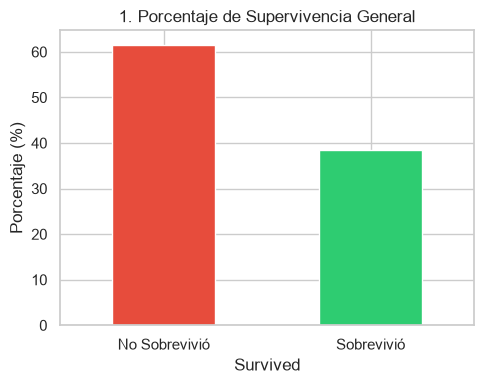

In [70]:
# Gráfico 1: Supervivencia General
plt.figure(figsize=(5, 4))
df['Survived'].value_counts(normalize=True).mul(100).plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('1. Porcentaje de Supervivencia General')
plt.ylabel('Porcentaje (%)')
plt.xticks([0, 1], ['No Sobrevivió', 'Sobrevivió'], rotation=0)
plt.tight_layout()
plt.savefig('../outputs/resultados/1_supervivencia_general.png')
plt.show()

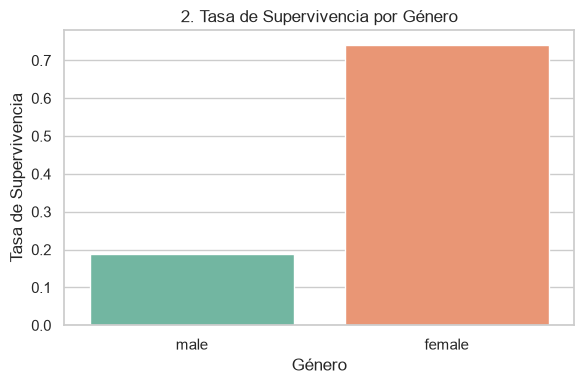

In [71]:
# Gráfico 2: Supervivencia por Género
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', hue='Sex', legend=False, data=df, errorbar=None, palette='Set2')
plt.title('2. Tasa de Supervivencia por Género')
plt.ylabel('Tasa de Supervivencia')
plt.xlabel('Género')
plt.tight_layout()
plt.savefig('../outputs/resultados/2_supervivencia_genero.png')
plt.show()

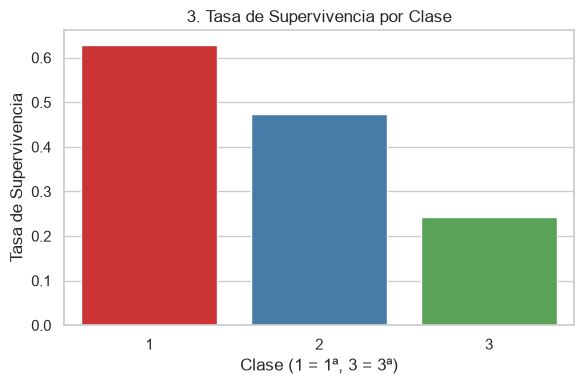

In [72]:
# Gráfico 3: Supervivencia por Clase de Pasajero
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', hue='Pclass', legend=False, data=df, errorbar=None, palette='Set1')
plt.title('3. Tasa de Supervivencia por Clase')
plt.ylabel('Tasa de Supervivencia')
plt.xlabel('Clase (1 = 1ª, 3 = 3ª)')
plt.tight_layout()
plt.savefig('../outputs/resultados/3_supervivencia_clase.png')
plt.show()

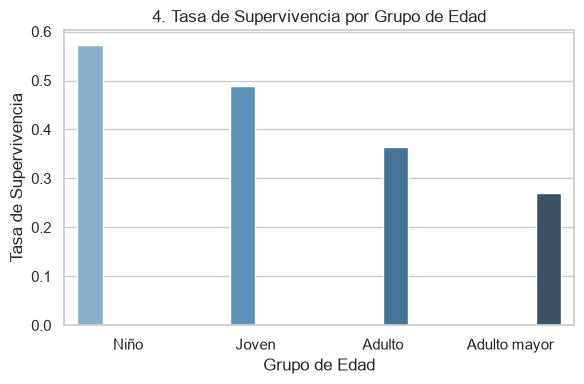

In [73]:
# Gráfico 4: Supervivencia por Grupos de Edad
plt.figure(figsize=(6, 4))
sns.barplot(x='AgeGroup', y='Survived', hue='AgeGroup', legend=False, data=df, errorbar=None, palette='Blues_d')
plt.title('4. Tasa de Supervivencia por Grupo de Edad')
plt.ylabel('Tasa de Supervivencia')
plt.xlabel('Grupo de Edad')
plt.tight_layout()
plt.savefig('../outputs/resultados/4_supervivencia_edad.png')
plt.show()

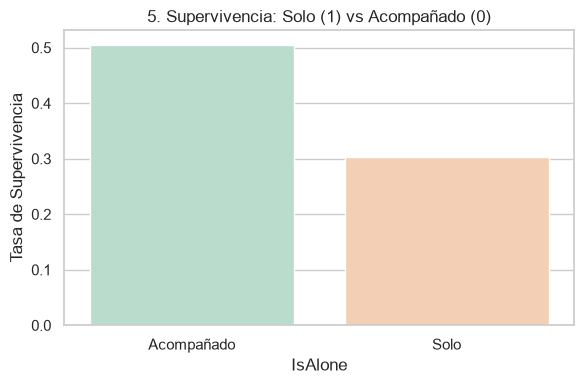

In [74]:
# Gráfico 5: Supervivencia según Acompañamiento (Solo vs Acompañado)
plt.figure(figsize=(6, 4))
sns.barplot(x='IsAlone', y='Survived', hue='IsAlone', legend=False, data=df, errorbar=None, palette='Pastel2')
plt.title('5. Supervivencia: Solo (1) vs Acompañado (0)')
plt.ylabel('Tasa de Supervivencia')
plt.xticks([0, 1], ['Acompañado', 'Solo'])
plt.tight_layout()
plt.savefig('../outputs/resultados/5_supervivencia_acompanado.png')
plt.show()

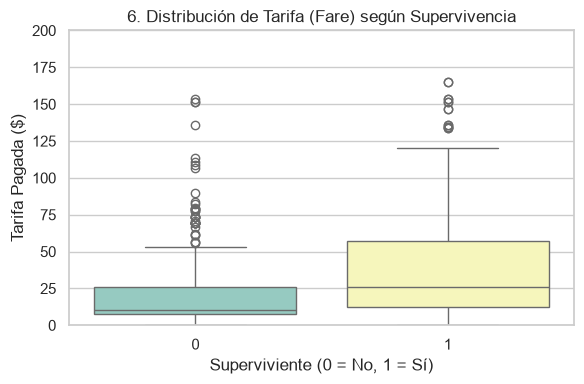

In [75]:
# Gráfico 6: Relación entre Tarifa Pagada y Supervivencia
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Fare', hue='Survived', legend=False, data=df, palette='Set3')
plt.title('6. Distribución de Tarifa (Fare) según Supervivencia')
plt.xlabel('Superviviente (0 = No, 1 = Sí)')
plt.ylabel('Tarifa Pagada ($)')
plt.ylim(0, 200)
plt.tight_layout()
plt.savefig('../outputs/resultados/6_supervivencia_tarifa.png')
plt.show()

In [76]:
reporte = f"""
INFORME FINAL: PROCESAMIENTO Y ANÁLISIS DE DATOS DEL TITANIC


1. RESUMEN DE LIMPIEZA Y TRANSFORMACIÓN DE DATOS

- Registros analizados: {num_pasajeros} filas, {num_columnas} columnas iniciales.
- Registros duplicados detectados: {duplicados}.
- Imputación de nulos realizada:
    * Age: Se imputó con la mediana ({df['Age'].median():.1f} años) para evitar distorsión por valores extremos.
    * Embarked: Se imputó con la moda ('{df['Embarked'].mode()[0]}'), correspondiente al puerto con más abordajes.
    * Cabin: Se rellenó con la categoría 'Desconocido' (687 faltantes, ~77% del total).
- Nuevas variables creadas:
    * FamilySize: Suma de SibSp + Parch + 1 (mismo pasajero).
    * IsAlone: Indicador binario (1 = Pasajero viajaba solo, 0 = Acompañado).
    * AgeGroup: Categorización por rangos [Niño, Joven, Adulto, Adulto mayor].


2.- RESPUESTAS A LAS 6 PREGUNTAS DEL ANÁLISIS

[1] ¿Qué porcentaje de pasajeros sobrevivió?
    R/ Sobrevivió el {pct_supervivencia:.2f}% de la muestra (342 de 891 pasajeros).

[2] ¿Cómo cambia la supervivencia entre hombres y mujeres?
    R/ Las mujeres tuvieron una tasa de supervivencia del {surv_sex['female']:.2f}%, 
       mientras que los hombres alcanzaron solo el {surv_sex['male']:.2f}%.

[3] ¿Cómo cambia la supervivencia según la clase del pasajero?
    R/ 1ª Clase: {surv_class[1]:.2f}% de supervivencia.
       2ª Clase: {surv_class[2]:.2f}% de supervivencia.
       3ª Clase: {surv_class[3]:.2f}% de supervivencia.

[4] ¿Qué grupos de edad presentan mayor supervivencia?
    R/ Los niños registraron la mayor supervivencia con un {surv_age['Niño']:.2f}%, 
       seguidos de jóvenes ({surv_age['Joven']:.2f}%), adultos ({surv_age['Adulto']:.2f}%) 
       y adultos mayores ({surv_age['Adulto mayor']:.2f}%).

[5] ¿Viajar solo o acompañado parece estar relacionado con la supervivencia?
    R/ Sí. Pasajeros acompañados sobrevivieron en un {surv_alone[0]:.2f}%, 
       frente a un {surv_alone[1]:.2f}% de los que viajaban solos.

[6] ¿Existe alguna relación entre la tarifa pagada y la supervivencia?
    R/ Sí. La tarifa media pagada por los supervivientes fue de ${fare_surv[1]:.2f}, 
       frente a ${fare_surv[0]:.2f} pagados por quienes fallecieron.


3.- CONCLUSIONES Y RECOMENDACIONES TÉCNICAS

- Protocolo Social: El principio "mujeres y niños primero" se refleja claramente en los datos 
  con las tasas más altas de supervivencia asociadas a dichos grupos demográficos.
- Brecha Socioeconómica: La ubicación en el barco y la prioridad de acceso a los botes salvavidas 
  favorecieron a las clases más altas (1ª y 2ª clase) y con tarifas más elevadas.
- Red de Apoyo: Viajar con familiares o acompañantes incrementó en más de 20 puntos porcentuales 
  las probabilidades de supervivencia en comparación con viajar solo.
"""

# Guardar informe formateado en outputs/resultados/conclusiones.txt
with open('../outputs/resultados/conclusiones.txt', 'w', encoding='utf-8') as f:
    f.write(reporte)

# Imprimir pantalla para verificación en VS Code
print(reporte)


INFORME FINAL: PROCESAMIENTO Y ANÁLISIS DE DATOS DEL TITANIC


1. RESUMEN DE LIMPIEZA Y TRANSFORMACIÓN DE DATOS

- Registros analizados: 891 filas, 12 columnas iniciales.
- Registros duplicados detectados: 0.
- Imputación de nulos realizada:
    * Age: Se imputó con la mediana (28.0 años) para evitar distorsión por valores extremos.
    * Embarked: Se imputó con la moda ('S'), correspondiente al puerto con más abordajes.
    * Cabin: Se rellenó con la categoría 'Desconocido' (687 faltantes, ~77% del total).
- Nuevas variables creadas:
    * FamilySize: Suma de SibSp + Parch + 1 (mismo pasajero).
    * IsAlone: Indicador binario (1 = Pasajero viajaba solo, 0 = Acompañado).
    * AgeGroup: Categorización por rangos [Niño, Joven, Adulto, Adulto mayor].


2.- RESPUESTAS A LAS 6 PREGUNTAS DEL ANÁLISIS

[1] ¿Qué porcentaje de pasajeros sobrevivió?
    R/ Sobrevivió el 38.38% de la muestra (342 de 891 pasajeros).

[2] ¿Cómo cambia la supervivencia entre hombres y mujeres?
    R/ Las mujeres 